In [66]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/julian3833/jigsaw-toxic-comment-classification-challenge/sample_submission.csv
/kaggle/input/datasets/julian3833/jigsaw-toxic-comment-classification-challenge/test_labels.csv
/kaggle/input/datasets/julian3833/jigsaw-toxic-comment-classification-challenge/train.csv
/kaggle/input/datasets/julian3833/jigsaw-toxic-comment-classification-challenge/test.csv


In [67]:
import os
os.environ["USE_TF"] = "0"
os.environ["TRANSFORMERS_NO_TF"] = "1"

import seaborn as sns

from sklearn.metrics import (
    precision_recall_fscore_support,
    f1_score,
    multilabel_confusion_matrix
)

from datasets import Dataset
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from transformers import AutoTokenizer, AutoModel, AutoModelForSequenceClassification, Trainer, TrainingArguments
import torch
from datasets import Dataset
from peft import LoraConfig, get_peft_model

In [68]:
TARGET = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']


df = pd.read_csv('/kaggle/input/datasets/julian3833/jigsaw-toxic-comment-classification-challenge/train.csv')
# df = pd.read_csv('data/train.csv')

In [69]:
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

distilbert_model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased", 
    num_labels=6
    )


def preprocess(examples):
    tokens = tokenizer(
        examples['comment_text'],
        padding='max_length',
        truncation=True,
        max_length=256
    )

    labels = [float(examples[label]) for label in TARGET]
    tokens['labels'] = labels
    return tokens

cols = ['comment_text'] + TARGET
train_pd, val_pd  = train_test_split(df[cols], test_size=0.2, random_state=42)


train_df = Dataset.from_pandas(train_pd)
train_ds = train_df.map(preprocess, batched=False)
train_ds.set_format(type='torch', columns=['input_ids', 'attention_mask', 'labels'])
val_df = Dataset.from_pandas(val_pd)
val_ds = val_df.map(preprocess, batched=False)
val_ds.set_format(type='torch', columns=['input_ids', 'attention_mask', 'labels']) 


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Map:   0%|          | 0/127656 [00:00<?, ? examples/s]

Map:   0%|          | 0/31915 [00:00<?, ? examples/s]

In [70]:


config = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=["q_lin", "v_lin"],
    lora_dropout=0.1,
    bias="none",
    task_type="SEQ_CLS"
)

lora_model = get_peft_model(distilbert_model, config)
lora_model.config.problem_type = "multi_label_classification"
lora_model.print_trainable_parameters()
device = torch.device("cuda")
lora_model.to(device)


training_args = TrainingArguments(
    output_dir="./toxic_lora",
    learning_rate=2e-5,
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    save_strategy="epoch",
    logging_dir="./logs",
    logging_steps=500,
)

def compute_metrics(eval_pred, treshold=0.5):
    logits, labels = eval_pred
    probs = torch.sigmoid(torch.tensor(logits)).numpy()
    preds = (probs >= treshold).astype(int)
    return {
        "f1_micro": f1_score(labels, preds, average="micro"),
        "f1_macro": f1_score(labels, preds, average="macro")
    }

trainer = Trainer(
    model=lora_model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics
)





# print("\n" + "="*80)
# print("Метрики BERT модели:")
# print("="*80)
# best_thresholds, best_scores = find_optimal_threshold(val_df[TARGET].values, val_probs)
# print("\nМетрики с оптимальными порогами:")
# metrics_model(val_df[TARGET], val_probs, thresholds=best_thresholds)
# print(f'\nValidation ROC-AUC Score (BERT): {roc_auc_score(val_df[TARGET], val_probs):.4f}')

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


trainable params: 742,662 || all params: 67,700,748 || trainable%: 1.0970


In [71]:
trainer.train()

Step,Training Loss
500,0.211653
1000,0.081663
1500,0.057950
2000,0.057740
2500,0.059293
3000,0.058656
3500,0.052659
4000,0.052515
4500,0.052637
5000,0.051576


TrainOutput(global_step=23937, training_loss=0.051503040938268414, metrics={'train_runtime': 3459.172, 'train_samples_per_second': 110.711, 'train_steps_per_second': 6.92, 'total_flos': 2.580405942627533e+16, 'train_loss': 0.051503040938268414, 'epoch': 3.0})

In [72]:
eval_results = trainer.evaluate()
print("\n" + "="*80)
print("Метрики LoRa BERT модели:")
print("="*80)
for metric_name, metric_value in eval_results.items():
    print(f"{metric_name}: {metric_value}")

    


Метрики LoRa BERT модели:
eval_loss: 0.04251546412706375
eval_f1_micro: 0.7610526315789473
eval_f1_macro: 0.458254773655659
eval_runtime: 119.6056
eval_samples_per_second: 266.835
eval_steps_per_second: 16.68
epoch: 3.0


In [86]:
eval_results

{'eval_loss': 0.04251546412706375,
 'eval_f1_micro': 0.7610526315789473,
 'eval_f1_macro': 0.458254773655659,
 'eval_runtime': 119.6056,
 'eval_samples_per_second': 266.835,
 'eval_steps_per_second': 16.68,
 'epoch': 3.0}

In [73]:
lora_model.save_pretrained("/kaggle/working/toxic_lora_adapter")

In [74]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    precision_recall_fscore_support,
    f1_score,
    multilabel_confusion_matrix
)

from datasets import Dataset

In [92]:
pred = trainer.predict(val_ds)

logits = pred.predictions
labels = pred.label_ids

probs = 1/(1+np.exp(-logits))
preds = (probs > 0.5).astype(int)

In [100]:
precision, recall, f1, support = precision_recall_fscore_support(
    labels,
    preds,
    average=None
)

metrics_df = pd.DataFrame({
    "class": TARGET,
    "precision": precision,
    "recall": recall,
    "f1": f1,
    "support": support
})

print(f'Validation ROC-AUC Score (BERT+LoRa): {roc_auc_score(labels, logits):.4}')
display(metrics_df)

Validation ROC-AUC Score (BERT+LoRa): 0.9853


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,class,precision,recall,f1,support
0,toxic,0.844366,0.784686,0.813433,3056
1,severe_toxic,0.598214,0.208723,0.309469,321
2,obscene,0.834429,0.813994,0.824085,1715
3,threat,0.000000,0.000000,0.000000,74
4,insult,0.750000,0.737918,0.743910,1614
5,identity_hate,0.692308,0.030612,0.058632,294


In [101]:
print("F1 micro:", f1_score(labels, preds, average="micro"))
print("F1 macro:", f1_score(labels, preds, average="macro"))

F1 micro: 0.7610526315789473
F1 macro: 0.458254773655659


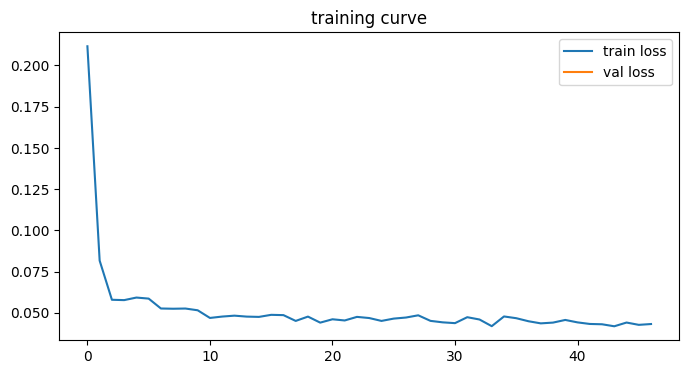

In [79]:
logs = trainer.state.log_history

train_loss = [x["loss"] for x in logs if "loss" in x]
eval_loss = [x["eval_loss"] for x in logs if "eval_loss" in x]

plt.figure(figsize=(8,4))

plt.plot(train_loss,label="train loss")
plt.plot(eval_loss,label="val loss")

plt.legend()
plt.title("training curve")

plt.show()

In [80]:
sample_texts = val_pd["comment_text"].head(5).tolist()

pred_table = pd.DataFrame({"text": sample_texts})
for i, label in enumerate(TARGET):
    pred_table[label] = probs[:5, i]

display(pred_table)

,text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,"Geez, are you forgetful! We've already discus...",0.244582,0.000253,0.011977,0.000960,0.062660,0.004754
1,Carioca RFA \n\nThanks for your support on my ...,0.000792,0.000012,0.000248,0.000166,0.000152,0.000029
2,"""\n\n Birthday \n\nNo worries, It's what I do ...",0.002206,0.000014,0.000493,0.000078,0.000350,0.000077
3,Pseudoscience category? \n\nI'm assuming that ...,0.001180,0.000005,0.000154,0.000050,0.000124,0.000068
4,"(and if such phrase exists, it would be provid...",0.000202,0.000003,0.000071,0.000024,0.000033,0.000017


In [81]:
test_df = pd.read_csv(
    "/kaggle/input/datasets/julian3833/jigsaw-toxic-comment-classification-challenge/test.csv"
)

test_dataset = Dataset.from_pandas(test_df)


In [ ]:
MAX_LENGTH = min(256, tokenizer.model_max_length)

def _safe_text(value):
    if value is None:
        return ""
    return str(value).replace("\n", " ").strip()

def tokenize_test(example):
    comment_text = _safe_text(example.get("comment_text", ""))
    context_text = _safe_text(example.get("context_text", ""))
    if context_text:
        pair_special = tokenizer.num_special_tokens_to_add(pair=True)
        comment_ids = tokenizer.encode(comment_text, add_special_tokens=False, truncation=False)
        if len(comment_ids) >= MAX_LENGTH - pair_special:
            return tokenizer(
                comment_text,
                padding="max_length",
                truncation=True,
                max_length=MAX_LENGTH
            )
        return tokenizer(
            comment_text,
            context_text,
            padding="max_length",
            truncation="only_second",
            max_length=MAX_LENGTH
        )
    return tokenizer(
        comment_text,
        padding="max_length",
        truncation=True,
        max_length=MAX_LENGTH
    )

test_dataset = test_dataset.map(tokenize_test)
test_dataset.set_format(type="torch", columns=["input_ids", "attention_mask"])

Map:   0%|          | 0/153164 [00:00<?, ? examples/s]

In [83]:
test_pred = trainer.predict(test_dataset)

logits = test_pred.predictions
probs = 1/(1+np.exp(-logits))

In [84]:
submission = pd.DataFrame(
    probs,
    columns=TARGET
)

submission.insert(0,"id",test_df["id"])

submission.to_csv("submission.csv",index=False)

display(submission.head())

,id,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,00001cee341fdb12,0.989442,0.371108,0.971314,0.067762,0.917957,0.234491
1,0000247867823ef7,0.002034,0.000010,0.000364,0.000136,0.000201,0.000053
2,00013b17ad220c46,0.003177,0.000088,0.001528,0.000167,0.000516,0.000256
3,00017563c3f7919a,0.000487,0.000007,0.000129,0.000116,0.000096,0.000018
4,00017695ad8997eb,0.001735,0.000008,0.000325,0.000088,0.000141,0.000039


In [85]:
display(submission.head())

,id,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,00001cee341fdb12,0.989442,0.371108,0.971314,0.067762,0.917957,0.234491
1,0000247867823ef7,0.002034,0.000010,0.000364,0.000136,0.000201,0.000053
2,00013b17ad220c46,0.003177,0.000088,0.001528,0.000167,0.000516,0.000256
3,00017563c3f7919a,0.000487,0.000007,0.000129,0.000116,0.000096,0.000018
4,00017695ad8997eb,0.001735,0.000008,0.000325,0.000088,0.000141,0.000039
